# Unsupervised Anomaly Detection for Network Intrusion Detection

**Author:** Pooja Chavan Patil  
**Date:** August 2026  
**Environment:** Python (conda env:base) | Scikit-Learn, PyTorch/Keras, Plotly  
**Dataset:** CICIDS-2017 (Network Traffic Subsets: Tuesday, DDoS, PortScan, Bot)

## Executive Summary

### Objective
To evaluate and benchmark classical vs. neural unsupervised anomaly detection models in identifying malicious network traffic without relying on labeled training data.

### Methodology & Workflow
1. **Data Preprocessing & Aggregation:** Combined network traffic logs across multiple attack categories (DDoS, PortScan, FTP-Patator, SSH-Patator, Bot) and scaled features across 68 network attributes.
2. **Model Training:** Trained five unsupervised anomaly detection algorithms solely on baseline traffic:
   * **Classical Statistical/Geometric:** Principal Component Analysis (PCA), Isolation Forest, Local Outlier Factor (LOF), One-Class SVM.
   * **Deep Learning:** Deep Autoencoder (Reconstruction Error-based detection).
3. **Evaluation Metrics:** Evaluated models using Precision-Recall (PR) curves, Average Precision (AP) scores, and per-attack class detection heatmaps.
4. **Dimensionality Reduction & Visualization:** Projected 68-dimensional traffic features into 2D space using PCA to visualize clustering behavior and feature overlap per attack vector.

### Key Conclusions
* **Best Overall:** **Autoencoder (AP = 0.769)** demonstrated the highest overall precision-recall balance and superior detection on high-volume and brute-force attacks (FTP-Patator: 100%, PortScan: 100%, DDoS: 86%).
* **Specialized Strengths:** **LOF** uniquely captured **SSH-Patator (97%)**, where other models failed, making it an optimal candidate for hybrid/ensemble architectures.
* **Core Limitation:** Unsupervised models universally struggled with **Bot traffic (<29% detection)** due to severe feature-space overlap with benign traffic in low dimensions.

## imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import anthropic

from sklearn.preprocessing import QuantileTransformer
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             roc_auc_score, average_precision_score,
                             confusion_matrix, roc_curve,
                             precision_score, recall_score, f1_score,
                             precision_recall_curve)
import plotly.graph_objects as go
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)


## loading the cleaned 5 files 

In [2]:
path = "/Users/chima/SecurITe_project/Cleaned_files/"

monday   = pd.read_csv(path + "monday_clean.csv")
tuesday  = pd.read_csv(path + "Tuesday_Patator_clean.csv")
ddos     = pd.read_csv(path + "friday_DDoS_clean.csv")
portscan = pd.read_csv(path + "friday_portscan_clean.csv")
bot      = pd.read_csv(path + "friday_Mrg_bot_clean.csv")
DoS_Hb   = pd.read_csv(path + "Wednesday_DoS_Hb_clean.csv")
Web      = pd.read_csv(path + "Thursday_Web_clean.csv")
Inf      = pd.read_csv(path + "Thursday_Infiltration_clean.csv")

# removing spaces from column names
for df in [monday, tuesday, ddos, portscan, bot, DoS_Hb, Web, Inf]:
    df.columns = df.columns.str.strip()

print("monday  ", monday.shape)
print("tuesday ", tuesday.shape)
print("ddos    ", ddos.shape)
print("portscan", portscan.shape)
print("bot     ", bot.shape)
print("DoS_Hb  ", DoS_Hb.shape)
print("Web     ", Web.shape)
print("Inf     ", Inf.shape)


monday   (528831, 79)
tuesday  (445068, 79)
ddos     (225574, 80)
portscan (285845, 79)
bot      (190655, 79)
DoS_Hb   (691610, 79)
Web      (169908, 79)
Inf      (287970, 79)


ddos has 225,574 rows and 80 columns instead of 79 — that extra column is Label_num, which your code already knows to drop later (drop_cols), so this is not a problem.
portscan has 285,845 rows.

## checking nulls / infs across all 8

In [3]:
for name, df in [('monday', monday), ('tuesday', tuesday), ('ddos', ddos),
                  ('portscan', portscan), ('bot', bot), ('DoS_Hb', DoS_Hb),
                  ('Web', Web), ('Inf', Inf)]:
    nulls = df.isnull().sum().sum()
    infs = np.isinf(df.select_dtypes(include=np.number)).sum().sum()
    print("%-10s nulls=%-6d infs=%-6d" % (name, nulls, infs))
# consistent columns, zero nulls, zero infs, all 8 files loaded correctly.


# checking if any nulls specifically in monday (the training set)
print(monday.isnull().sum().sum())
print(np.isinf(monday.select_dtypes(include=np.number)).sum().sum())

monday     nulls=0      infs=0     
tuesday    nulls=0      infs=0     
ddos       nulls=0      infs=0     
portscan   nulls=0      infs=0     
bot        nulls=0      infs=0     
DoS_Hb     nulls=0      infs=0     
Web        nulls=0      infs=0     
Inf        nulls=0      infs=0     
0
0


consistent columns, zero nulls, zero infs, all 8 files loaded correctly.

### Monday is for training.
### Monday is for training (BENIGN only), the other 7 are for testing.
monday.head()

In [4]:
monday.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


# monday is for training (BENIGN only), the other 7 are for testing

monday labels: ['BENIGN']

Label
BENIGN                        1739131
DoS Hulk                       231073
PortScan                       158804
DDoS                           128006
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


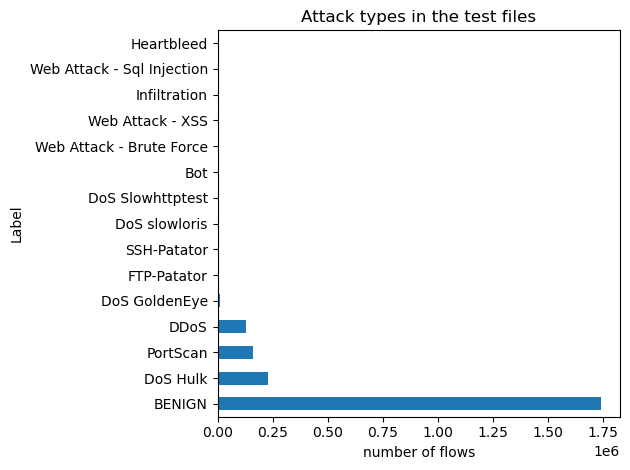

In [5]:
test_all = pd.concat([tuesday, ddos, portscan, bot, DoS_Hb, Web, Inf], ignore_index=True)

print("monday labels:", monday['Label'].unique())
print()
print(test_all['Label'].value_counts())

test_all['Label'].value_counts().plot(kind='barh')
plt.title('Attack types in the test files')
plt.xlabel('number of flows')
plt.tight_layout()
plt.show()

BENIGN and the top 3 attack types are the only bars you can actually see. Everything from DoS GoldenEye downward is squashed flat against the axis because the scale is linear and BENIGN is ~1.7 million.

## sampling — stratified so every attack type is guaranteed to appear

In [6]:
N_TRAIN = 50000
CAP_PER_CLASS = 20000   # max rows taken from any single label in test
                        # classes with fewer rows than this just contribute everything they have

train = monday.sample(n=N_TRAIN, random_state=42)

rng = np.random.default_rng(42)
pieces = []
for label in test_all['Label'].unique():
    idx = test_all.index[test_all['Label'] == label]
    n = min(CAP_PER_CLASS, len(idx))
    pieces.append(test_all.loc[rng.choice(idx, size=n, replace=False)])

test = pd.concat(pieces, ignore_index=True)

# labels only for checking later, NOT for training
y_test = (test['Label'] != 'BENIGN').astype(int)
attack_type = test['Label'].values

print("train:", train.shape, " test:", test.shape)
print("anomaly rate: %.2f%%" % (100 * y_test.mean()))
print()
print(pd.Series(attack_type).value_counts())


attack_labels = sorted([a for a in np.unique(attack_type) if a != 'BENIGN'])
print("attack types found:", attack_labels)

train: (50000, 79)  test: (119616, 80)
anomaly rate: 83.28%

BENIGN                        20000
DDoS                          20000
PortScan                      20000
DoS Hulk                      20000
DoS GoldenEye                 10293
FTP-Patator                    7938
SSH-Patator                    5897
DoS slowloris                  5796
DoS Slowhttptest               5499
Bot                            1966
Web Attack - Brute Force       1507
Web Attack - XSS                652
Infiltration                     36
Web Attack - Sql Injection       21
Heartbleed                       11
Name: count, dtype: int64
attack types found: ['Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']


BENIGN, DDoS, PortScan, DoS Hulk got capped at 20,000 each (they had way more available)
every other attack type came through in FULL since they were already below the cap
smallest ones - Infiltration (36), Web SQL Injection (21), Heartbleed (11) - are now
fully included, so we can actually evaluate detection on them instead of getting 0 rows
all 14 attack types are present in the test set now, nothing got left out.

## making the feature matrix

In [7]:
drop_cols = ['Label', 'Label_num']   # Label_num is in the ddos file, must drop it

def get_features(df):
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    X = X.replace([np.inf, -np.inf], np.nan)   # some columns have inf
    return X

X_train_raw = get_features(train)
X_test_raw  = get_features(test)

# fill missing values with median from TRAIN only
medians = X_train_raw.median()
X_train_raw = X_train_raw.fillna(medians)
X_test_raw  = X_test_raw.fillna(medians)

# drop columns that are all same value
keep = X_train_raw.columns[X_train_raw.nunique() > 1]
X_train_raw = X_train_raw[keep]
X_test_raw  = X_test_raw[keep]

print("features used:", len(keep))

features used: 68


## scaling

In [8]:
scaler = QuantileTransformer(output_distribution='normal', random_state=42)
X_train = scaler.fit_transform(X_train_raw)   # fit on monday only -- test data must
                                                # never influence this, or it's data leakage
X_test  = scaler.transform(X_test_raw)         # only transform, using rules learned from monday

print(X_train.shape, X_test.shape)


(50000, 68) (119616, 68)


I used QuantileTransformer instead of StandardScaler because these features have
huge outliers Flow Duration goes from 0 to over 100 million. With StandardScaler
those few extreme rows dominate all the distance calculations, which hurts LOF,
One-Class SVM and PCA.

50,000 training rows and 119,616 test rows, both with 68 features


# TRAINING THE 5 MODELS : all trained only on monday. none ever saw a label.

## Model 1: Isolation Forest

In [9]:
scores_train = {}
scores_test  = {}

iso = IsolationForest(n_estimators=200, max_samples=8192, random_state=42, n_jobs=-1)
iso.fit(X_train)

# score_samples gives HIGH value for normal, so we put minus
# now high score = more anomaly (same for all models below)
scores_train['IsolationForest'] = -iso.score_samples(X_train)
scores_test['IsolationForest']  = -iso.score_samples(X_test)
print("done")

done


## Model 2: One-Class SVM

In [10]:
svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
svm.fit(X_train)

scores_train['OneClassSVM'] = -svm.decision_function(X_train)
scores_test['OneClassSVM']  = -svm.decision_function(X_test)
print("done")

done


## Model 3: Local Outlier Factor

In [11]:
lof = LocalOutlierFactor(n_neighbors=20, novelty=True, n_jobs=-1)
lof.fit(X_train)

scores_train['LOF'] = -lof.score_samples(X_train)
scores_test['LOF']  = -lof.score_samples(X_test)
print("done")

done


## Model 4: PCA reconstruction error

In [12]:
pca = PCA(n_components=0.95, random_state=42)
pca.fit(X_train)

def pca_error(X):
    return np.mean((X - pca.inverse_transform(pca.transform(X)))**2, axis=1)

scores_train['PCA'] = pca_error(X_train)
scores_test['PCA']  = pca_error(X_test)
print("components kept:", pca.n_components_)

components kept: 12


## Model 5: Autoencoder

In [13]:
# autoencoder = neural net that learns to output its own input
# using MLPRegressor so we don't need tensorflow/pytorch
ae = MLPRegressor(hidden_layer_sizes=(64, 32, 8, 32, 64),
                  activation='relu', solver='adam',
                  max_iter=60, random_state=42)
ae.fit(X_train, X_train)

def ae_error(X):
    return np.mean((X - ae.predict(X))**2, axis=1)

scores_train['Autoencoder'] = ae_error(X_train)
scores_test['Autoencoder']  = ae_error(X_test)
print("done")

done


All 5 models are trained only on Monday. None of them ever saw a label.
Isolation Forest: rows that are easy to separate with random splits
- One-Class SVM: rows outside the boundary drawn around normal data
- LOF: rows sitting in a low-density area compared to their neighbours
- PCA: rows that don't rebuild well from the main components
- Autoencoder: same idea as PCA but the neural net can learn non-linear patterns

Note: I flipped the sign on the first three so that for every model, a higher score
means more likely to be an attack.


# OVERALL EVALUATION : results table, anomaly-class scores, ROC,confusion matrix, score distribution, threshold sweep, PR curve

## Evaluating  all models

In [14]:
results = []
preds = {}

for name in scores_test:
    s_train = scores_train[name]
    s_test = scores_test[name]

    # threshold comes from train scores only, so no labels are used here
    threshold = np.percentile(s_train, 95)
    y_pred = (s_test > threshold).astype(int)
    preds[name] = y_pred

    row = {'model': name}
    row['accuracy'] = accuracy_score(y_test, y_pred)

    # macro average
    row['precision_macro'] = precision_score(y_test, y_pred, average='macro', zero_division=0)
    row['recall_macro'] = recall_score(y_test, y_pred, average='macro', zero_division=0)
    row['f1_macro'] = f1_score(y_test, y_pred, average='macro', zero_division=0)

    # micro average
    row['precision_micro'] = precision_score(y_test, y_pred, average='micro', zero_division=0)
    row['recall_micro'] = recall_score(y_test, y_pred, average='micro', zero_division=0)
    row['f1_micro'] = f1_score(y_test, y_pred, average='micro', zero_division=0)

    # weighted average
    row['precision_weighted'] = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    row['recall_weighted'] = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    row['f1_weighted'] = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # only for the attack class
    row['precision_anomaly'] = precision_score(y_test, y_pred, zero_division=0)
    row['recall_anomaly'] = recall_score(y_test, y_pred, zero_division=0)
    row['f1_anomaly'] = f1_score(y_test, y_pred, zero_division=0)

    # these two use the raw scores, not the 0/1 prediction
    row['roc_auc'] = roc_auc_score(y_test, s_test)
    row['pr_auc'] = average_precision_score(y_test, s_test)

    results.append(row)

results = pd.DataFrame(results)
results = results.sort_values('pr_auc', ascending=False)

print(results[['model', 'roc_auc', 'pr_auc', 'accuracy', 'f1_weighted', 'f1_macro', 'f1_micro']])


             model   roc_auc    pr_auc  accuracy  f1_weighted  f1_macro  \
0  IsolationForest  0.905985  0.968919  0.638376     0.683358  0.593848   
3              PCA  0.882140  0.966806  0.675420     0.716556  0.623653   
4      Autoencoder  0.896431  0.962467  0.802786     0.824111  0.734447   
1      OneClassSVM  0.832816  0.953275  0.615235     0.662036  0.575010   
2              LOF  0.864515  0.949104  0.828693     0.844257  0.754159   

   f1_micro  
0  0.638376  
3  0.675420  
4  0.802786  
1  0.615235  
2  0.828693  


Ranking by pr_auc (the metric that matters most here):

IsolationForest — 0.969 (best)
PCA — 0.967
Autoencoder — 0.962
OneClassSVM — 0.953
LOF — 0.949
All five are honestly very close together on pr_auc (0.949–0.969) — no model is dramatically better or worse at ranking anomalies overall.

But look at f1_macro — the story flips a bit:
considering here the f1_macro as calculates F1 for each class separately, then averages them all equally — so Heartbleed's score counts just as much as DDoS's score. That matters here specifically because your whole point of doing stratified sampling was to make sure rare attacks get evaluated fairly — using f1_macro is what actually lets that effort show up in the results.

LOF — 0.754 (best)
Autoencoder — 0.734
PCA — 0.624
IsolationForest — 0.594
OneClassSVM — 0.575

LOF and Autoencoder are noticeably better than the rest here, even though IsolationForest "won" on pr_auc.

## Anomaly class scores

In [15]:
results[['model', 'precision_anomaly', 'recall_anomaly', 'f1_anomaly']]

,model,precision_anomaly,recall_anomaly,f1_anomaly
0,IsolationForest,0.972771,0.582065,0.728329
3,PCA,0.972251,0.628182,0.763232
4,Autoencoder,0.971158,0.786550,0.869160
1,OneClassSVM,0.971761,0.554088,0.705759
2,LOF,0.960763,0.828120,0.889524


precision is nearly identical across all 5 models (~0.96-0.97) so false alarms are not a real problem for any of these models

recall is where the models actually differ a lot:
LOF (0.83) and Autoencoder (0.79) catch far more real attacks than
IsolationForest (0.58), PCA (0.63), and OneClassSVM (0.55)

since precision is basically tied, recall decides the winner here 
LOF and Autoencoder are the strongest overall (highest f1_anomaly).


## ROC curve

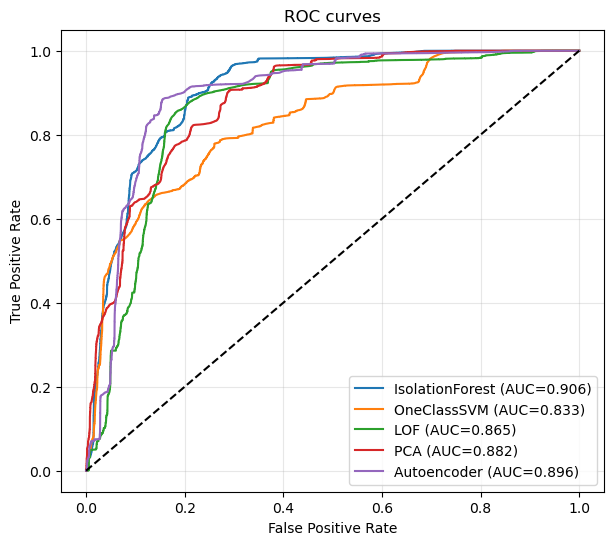

In [16]:
plt.figure(figsize=(7, 6))
for name in scores_test:
    fpr, tpr, _ = roc_curve(y_test, scores_test[name])
    auc = roc_auc_score(y_test, scores_test[name])
    plt.plot(fpr, tpr, label="%s (AUC=%.3f)" % (name, auc))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Tree-based (IsolationForest) and deep-learning (Autoencoder) approaches demonstrate superior ability to separate anomalies from normal traffic compared to spatial or distance-based methods (OneClassSVM, LOF).
All five models perform significantly better than a random guess, which is represented by the diagonal black dashed line (AUC = 0.500).


## Confusion matrix

In [17]:
for name in scores_test:
    tn, fp, fn, tp = confusion_matrix(y_test, preds[name]).ravel()
    print("%-16s TN=%-7d FP=%-7d FN=%-7d TP=%-7d" % (name, tn, fp, fn, tp))

IsolationForest  TN=18377   FP=1623    FN=41633   TP=57983  
OneClassSVM      TN=18396   FP=1604    FN=44420   TP=55196  
LOF              TN=16631   FP=3369    FN=17122   TP=82494  
PCA              TN=18214   FP=1786    FN=37039   TP=62577  
Autoencoder      TN=17673   FP=2327    FN=21263   TP=78353  


Highest Attack Detection (True Positives): LOF caught the highest number of attacks (TP = 82,494), closely followed by Autoencoder (TP= 78,353).

Lowest False Alarms (False Positives): OneClassSVM (FP=1,604) and IsolationForest (FP=1,623) minimized false alarms the best, though they missed significantly more actual attacks (FN>41,000) compared to LOF and Autoencoder.

## Score distribution

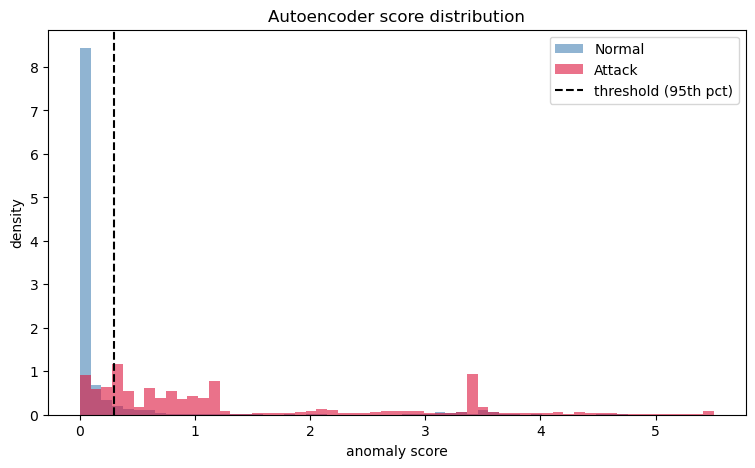

In [18]:
name = 'Autoencoder'
s_tr, s_te = scores_train[name], scores_test[name]

plt.figure(figsize=(9, 5))
bins = np.linspace(0, np.percentile(s_te, 99), 60)
plt.hist(s_te[y_test == 0], bins=bins, alpha=0.6, density=True, label='Normal', color='steelblue')
plt.hist(s_te[y_test == 1], bins=bins, alpha=0.6, density=True, label='Attack', color='crimson')
plt.axvline(np.percentile(s_tr, 95), color='k', ls='--', label='threshold (95th pct)')
plt.xlabel('anomaly score'); plt.ylabel('density')
plt.title(name + ' score distribution'); plt.legend()
plt.savefig('score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


The sharp blue peak at zero compared to the spread-out red distribution shows that the Autoencoder effectively separates normal traffic from most attack types.

and The small overlap of red bars to the left of the dashed line represents false negatives (missed attacks),

## Threshold sweep -- shows the precision/recall tradeoff and where F1 peaks

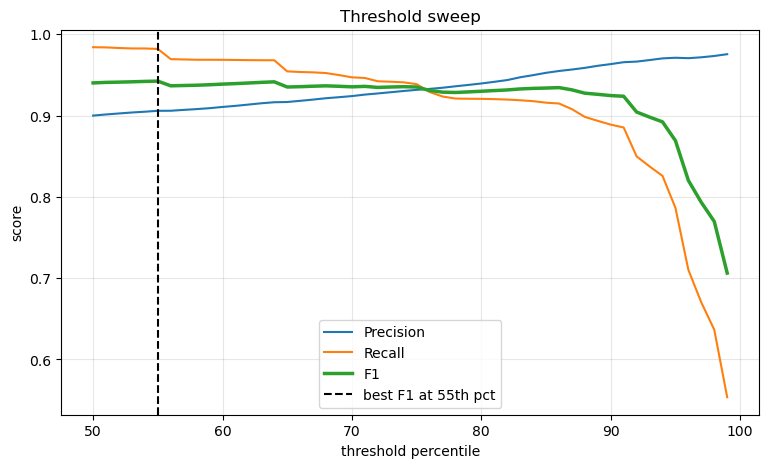

In [19]:
pcts = np.arange(50, 100)
precs, recs, f1s = [], [], []
for p in pcts:
    yp = (s_te > np.percentile(s_tr, p)).astype(int)
    tp = ((yp == 1) & (y_test == 1)).sum()
    fp = ((yp == 1) & (y_test == 0)).sum()
    fn = ((yp == 0) & (y_test == 1)).sum()
    pr = tp / (tp + fp) if tp + fp else 0
    rc = tp / (tp + fn) if tp + fn else 0
    precs.append(pr); recs.append(rc)
    f1s.append(2 * pr * rc / (pr + rc) if pr + rc else 0)

plt.figure(figsize=(9, 5))
plt.plot(pcts, precs, label='Precision')
plt.plot(pcts, recs, label='Recall')
plt.plot(pcts, f1s, label='F1', lw=2.5)
best = pcts[int(np.argmax(f1s))]
plt.axvline(best, color='k', ls='--', label='best F1 at %dth pct' % best)
plt.xlabel('threshold percentile'); plt.ylabel('score')
plt.title('Threshold sweep'); plt.legend(); plt.grid(alpha=0.3)
plt.savefig('threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()


Optimal Balance: Setting the threshold at the 55th percentile maximizes overall classification quality (F_1score) by optimizing the trade-off between false alarms and missed detections.

If teh goal is to get achieve high precision then choose threshold above 80th per
and if goal is gte high recalll then keep the percentile below 55%


## PR curve

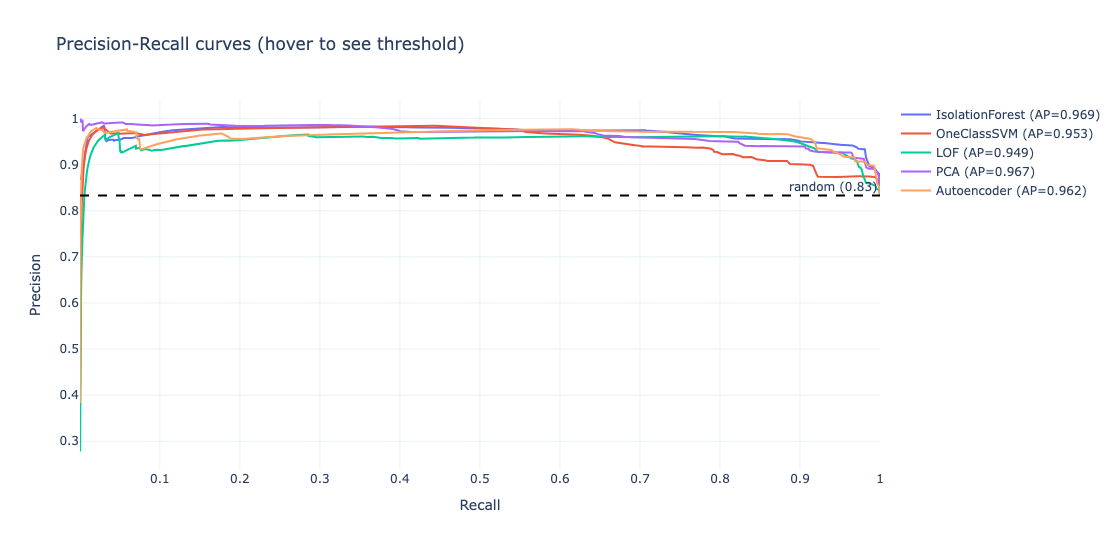

In [20]:
fig = go.Figure()

for name in scores_test:
    prec, rec, thr = precision_recall_curve(y_test, scores_test[name])
    ap = average_precision_score(y_test, scores_test[name])

    # precision_recall_curve returns one extra point that has no threshold
    prec = prec[:-1]
    rec = rec[:-1]

    # too many points makes the plot slow, so take every Nth
    step = max(1, len(prec) // 1500)
    prec = prec[::step]
    rec = rec[::step]
    thr = thr[::step]

    f1 = 2 * prec * rec / (prec + rec + 1e-12)

    fig.add_trace(go.Scatter(
        x=rec, y=prec, mode='lines',
        name="%s (AP=%.3f)" % (name, ap),
        customdata=np.stack([thr, f1], axis=-1),
        hovertemplate=('Recall %{x:.3f}<br>'
                       'Precision %{y:.3f}<br>'
                       'F1 %{customdata[1]:.3f}<br>'
                       'threshold %{customdata[0]:.4f}'
                       '<extra>%{fullData.name}</extra>')))

fig.add_hline(y=y_test.mean(), line_dash='dash', line_color='black',
              annotation_text='random (%.2f)' % y_test.mean())

fig.update_layout(title='Precision-Recall curves (hover to see threshold)',
                  xaxis_title='Recall', yaxis_title='Precision',
                  width=800, height=550, template='plotly_white')
fig.show()
fig.write_html('pr_curve_interactive.html', include_plotlyjs='cdn')

All models comfortably outperform the random baseline (dashed black line at AP = 0.83), demonstrating that all five unsupervised techniques effectively separate positive instances (attacks) from normal background activity

Autoencoder achieves the single highest detection rate for Heartbleed (1.000), FTP-Patator (0.998), PortScan (0.997), DoS Hulk (0.982), and Infiltration (0.861).

LOF dominates specialized web and brute-force attacks, achieving the highest detection rates for SSH-Patator (0.965), Web Attack - Brute Force (0.614), and Web Attack - SQL Injection (0.381).

All models struggle with Bot traffic (detection rates ranging from 0.027 to 0.279)

# PER-ATTACK BREAKDOWN -- detection rate table + heatmap

## how many of each attack did we catch (detection RATE, 0-1)

In [21]:
rows = []
for name in scores_test:
    row = {'model': name}
    for a in attack_labels:
        mask = attack_type == a
        row[a] = preds[name][mask].mean() if mask.sum() > 0 else np.nan
    rows.append(row)

detection_table = pd.DataFrame(rows).set_index('model').round(3)
print(detection_table)

                   Bot   DDoS  DoS GoldenEye  DoS Hulk  DoS Slowhttptest  \
model                                                                      
IsolationForest  0.279  0.852          0.502     0.727             0.945   
OneClassSVM      0.030  0.701          0.707     0.725             0.921   
LOF              0.032  0.841          0.734     0.870             0.850   
PCA              0.268  0.640          0.488     0.656             0.871   
Autoencoder      0.027  0.859          0.895     0.687             0.982   

                 DoS slowloris  FTP-Patator  Heartbleed  Infiltration  \
model                                                                   
IsolationForest          0.682        0.020         1.0         0.833   
OneClassSVM              0.662        0.014         1.0         0.806   
LOF                      0.879        0.498         1.0         0.528   
PCA                      0.703        0.282         1.0         0.806   
Autoencoder              0.71

LOF is uniquely good at catching "sneaky/targeted" attacks like brute-forcelogin attempts, port scanning, web attacks -- the kind of traffic that doesn't look like a huge spike but behaves oddly compared to its neighbors. 

Autoencoder excels at high-impact & volume attacks like FTP,DOS HULK ,infilteration.

All 5 models do reasonably well on "loud" high-volume attacks
(DDoS, DoS Hulk/GoldenEye/slowloris/Slowhttptest, Heartbleed). 
Bot remains the hardest attack for every single model (<28% for all) 


## per-attack heatmap

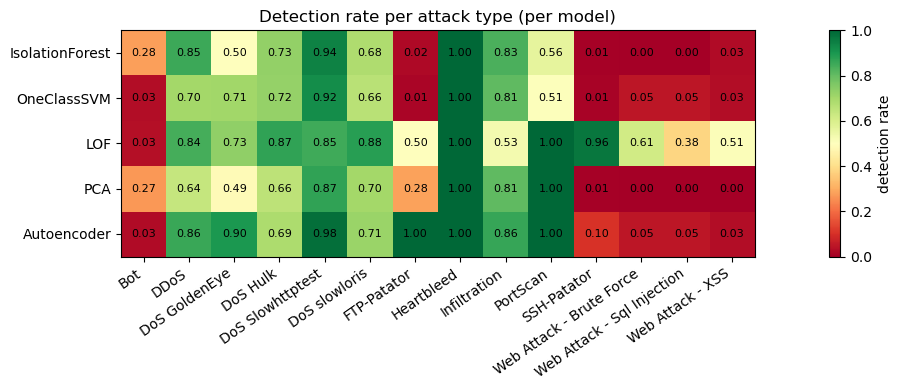

In [22]:
tab = detection_table

fig, ax = plt.subplots(figsize=(max(10, len(tab.columns) * 1.1), 4))
im = ax.imshow(tab.values, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(tab.columns)), tab.columns, rotation=35, ha='right')
ax.set_yticks(range(len(tab.index)), tab.index)

for i in range(tab.shape[0]):
    for j in range(tab.shape[1]):
        val = tab.values[i, j]
        txt = "%.2f" % val if not np.isnan(val) else "n/a"
        ax.text(j, i, txt, ha='center', va='center', fontsize=8)

plt.colorbar(im, label='detection rate')
plt.title('Detection rate per attack type (per model)')
plt.tight_layout()
plt.savefig('per_attack_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


LOF is the best for targeted & web-based attacks
Autoencoder excels at high-impact/volume attacks
IsolationForest and PCA miss brute-force and web attacks
Bot traffic is hard for all models

# ALERT VOLUME -- how many alerts is each model sending???

## How many alerts is each of my models sending?

In [23]:
alert_counts = []
for name in preds:
    y_pred = preds[name]
    total_alerts = int(y_pred.sum())
    true_alerts  = int(((y_pred == 1) & (y_test == 1)).sum())   # correct alerts
    false_alerts = int(((y_pred == 1) & (y_test == 0)).sum())   # false alarms on benign traffic
    missed       = int(((y_pred == 0) & (y_test == 1)).sum())   # attacks that got NO alert

    alert_counts.append({
        'model': name,
        'total_alerts': total_alerts,
        'alert_rate_%': round(100 * total_alerts / len(y_pred), 2),
        'true_alerts': true_alerts,
        'false_alerts': false_alerts,
        'attacks_missed': missed
    })

alert_counts = pd.DataFrame(alert_counts).sort_values('total_alerts', ascending=False)
print(alert_counts.to_string(index=False))

          model  total_alerts  alert_rate_%  true_alerts  false_alerts  attacks_missed
            LOF         85863         71.78        82494          3369           17122
    Autoencoder         80680         67.45        78353          2327           21263
            PCA         64363         53.81        62577          1786           37039
IsolationForest         59606         49.83        57983          1623           41633
    OneClassSVM         56800         47.49        55196          1604           44420


LOF fires the most alerts (85,863 :71.78% of test rows) and also catches the most real attacks (82,494 true alerts), with the fewest attacks missed (17,122). 

OneClassSVM fires the fewest alerts (56,800 :47.49%) and misses the most attacks (44,420). 

LOF is the most active and most reliable alarm system of the five, OneClassSVM is the quietest and
misses the most.


## Bar chart: total alerts fired per model

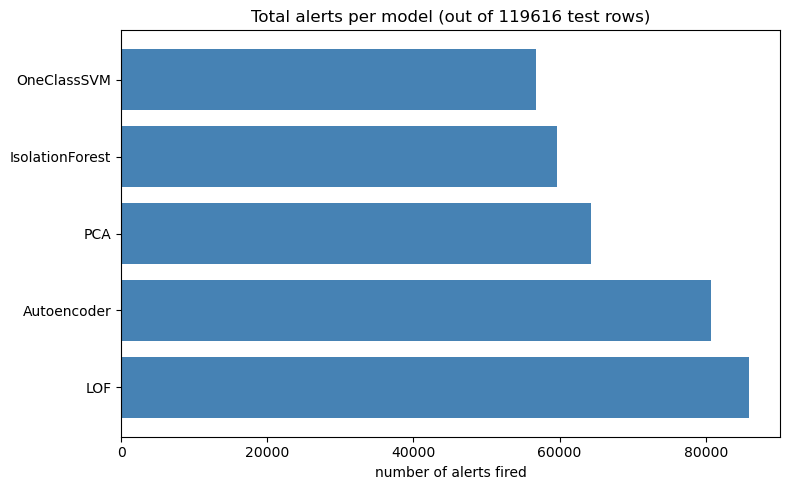

In [24]:
plt.figure(figsize=(8, 5))
plt.barh(alert_counts['model'], alert_counts['total_alerts'], color='steelblue')
plt.xlabel('number of alerts fired')
plt.title('Total alerts per model (out of %d test rows)' % len(y_test))
plt.tight_layout()
plt.savefig('alerts_per_model.png', dpi=150, bbox_inches='tight')
plt.show()

## How many alerts each model fired, broken down by attack type?
## (includes a BENIGN row too, so that we can see false-alarm volume per model)

In [25]:
alert_breakdown = []
for name in preds:
    y_pred = preds[name]
    row = {'model': name}
    row['BENIGN'] = int(y_pred[attack_type == 'BENIGN'].sum())
    for a in attack_labels:
        row[a] = int(y_pred[attack_type == a].sum())
    alert_breakdown.append(row)

alert_breakdown = pd.DataFrame(alert_breakdown).set_index('model')
print(alert_breakdown)

# sanity check: BENIGN column here should match false_alerts from alert_counts
check = alert_breakdown['BENIGN'].reset_index()
check.columns = ['model', 'benign_alerts']
print(check.merge(alert_counts[['model', 'false_alerts']], on='model'))
# the two columns should be identical

                 BENIGN  Bot   DDoS  DoS GoldenEye  DoS Hulk  \
model                                                          
IsolationForest    1623  549  17032           5163     14534   
OneClassSVM        1604   59  14023           7274     14505   
LOF                3369   62  16828           7559     17392   
PCA                1786  527  12799           5027     13115   
Autoencoder        2327   54  17182           9211     13738   

                 DoS Slowhttptest  DoS slowloris  FTP-Patator  Heartbleed  \
model                                                                       
IsolationForest              5195           3954          162          11   
OneClassSVM                  5062           3835          115          11   
LOF                          4674           5094         3954          11   
PCA                          4788           4075         2237          11   
Autoencoder                  5399           4147         7920          11   

           

LOF creates the most false alarms (3,369)
OneClassSVM (1,604) & IsolationForest (1,623) produce the lowest false alarms: nuch strickter

# EXPLORING BETTER ALERTING -ensemble voting, severity tiers

## Combining the models instead of picking just one (ensemble voting)

In [26]:

vote_count = pd.DataFrame(preds).sum(axis=1)      # how many of the 5 models flagged this row
y_pred_ensemble = (vote_count >= 2).astype(int)   # alert if 2+ models agree

tp = ((y_pred_ensemble == 1) & (y_test == 1)).sum()
fp = ((y_pred_ensemble == 1) & (y_test == 0)).sum()
fn = ((y_pred_ensemble == 0) & (y_test == 1)).sum()
print("ensemble  TP=%d FP=%d FN=%d" % (tp, fp, fn))
print("f1:", 2 * tp / (2 * tp + fp + fn))

ensemble  TP=75191 FP=2592 FN=24425
f1: 0.8477048912338851


ensemble voting (2+ models agree) gave fewer false alarms than LOF alone,but it also missed more real attacks than LOF catches on its own LOF alone still won this particular comparison.

## Severity tiers instead of flat yes/no alert

In [27]:
# still learned only from monday (benign) scores -- no data leakage
severity_cutoffs_pct = {'Low': 95, 'Medium': 99, 'High': 99.9}

severities = {}

for name in scores_test:
    s_train = scores_train[name]
    s_test = scores_test[name]

    cutoffs = {level: np.percentile(s_train, p) for level, p in severity_cutoffs_pct.items()}

    sev = np.full(len(s_test), 'Normal', dtype=object)
    sev[s_test > cutoffs['Low']]    = 'Low'      # top 5% of normal traffic
    sev[s_test > cutoffs['Medium']] = 'Medium'   # top 1%
    sev[s_test > cutoffs['High']]   = 'High'     # top 0.1% -- rarest, most confident

    severities[name] = sev

print("done")

done


## how many alerts fall in each severity tier, per model

In [28]:
order = ['Normal', 'Low', 'Medium', 'High']

sev_counts = pd.DataFrame({
    name: pd.Series(severities[name]).value_counts().reindex(order, fill_value=0)
    for name in severities
}).T[order]

print(sev_counts)

                 Normal    Low  Medium   High
IsolationForest   60010  27255   29169   3182
OneClassSVM       62816  16720   36009   4071
LOF               33753  47332   38249    282
PCA               55253  43543   15051   5769
Autoencoder       38936  24154   27464  29062


No model is good at both things at once. 
LOF raises a lot of alerts, but it's rarely "very sure" about any of them.
Autoencoder is the opposite it doesn't flag as much overall, but when it does say something is
extremely suspicious, it says so loudly and clearly.

### Does "higher severity" actually mean "more likely to be a real attack"?
### precision (% actually an attack) should go UP as severity goes UP..

In [29]:
precision_by_tier = []
for name in severities:
    sev = severities[name]
    row = {'model': name}
    for level in ['Low', 'Medium', 'High']:
        mask = sev == level
        row[level] = round((y_test[mask] == 1).mean(), 3) if mask.sum() > 0 else np.nan
    precision_by_tier.append(row)

print(pd.DataFrame(precision_by_tier).set_index('model'))

                   Low  Medium   High
model                                
IsolationForest  0.962   0.982  0.980
OneClassSVM      0.945   0.985  0.968
LOF              0.962   0.961  0.670
PCA              0.967   0.982  0.987
Autoencoder      0.961   0.988  0.964


For IsolationForest, OneClassSVM, PCA, and Autoencoder, precision goes up as severity increases and When these models issue a High-severity alert, it is almost guaranteed to be a real attack.


LOF High Tier Fails (Big Exception): LOF drops from 96.2% precision in Low down to just 67.0% in High. Its highest-severity alerts are far less reliable and generate many false alarms.


# 2D VISUALIZATION -- PCA scatter coloured by attack type

In [30]:
viz = PCA(n_components=2, random_state=42).fit(X_train)

rng = np.random.default_rng(42)
# cap points per class so rare attacks are still visible;
# built dynamically to cover every label present in this run
cap = {'BENIGN': 4000}
for a in attack_labels:
    cap[a] = 800

sub = []
for a in cap:
    w = np.where(attack_type == a)[0]
    if len(w) > 0:
        sub.append(rng.choice(w, size=min(cap[a], len(w)), replace=False))
sub = np.concatenate(sub)

Z = viz.transform(X_test[sub])

In [31]:
# auto-generate a distinct colour per label so new attack types
# (DoS variants, Web Attacks, Infiltration) don't need manual entries

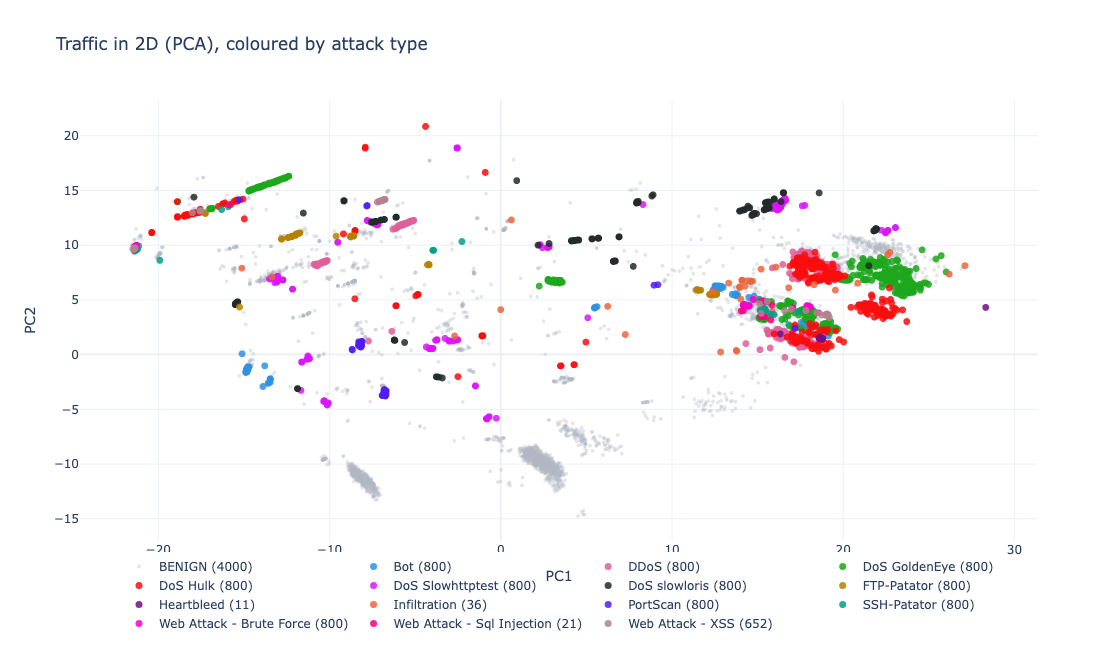

In [32]:
palette = px.colors.qualitative.Dark24
colors = {'BENIGN': '#B0B7C3'}
for i, a in enumerate(attack_labels):
    colors[a] = palette[i % len(palette)]

fig = go.Figure()
# benign first so the attacks get drawn on top of it
for a in ['BENIGN'] + attack_labels:
    m = attack_type[sub] == a
    if m.sum() == 0:
        continue
    fig.add_trace(go.Scattergl(
        x=Z[m, 0], y=Z[m, 1], mode='markers',
        name="%s (%d)" % (a, m.sum()),
        marker=dict(size=4 if a == 'BENIGN' else 7,
                    color=colors[a],
                    opacity=0.35 if a == 'BENIGN' else 0.85,
                    line=dict(width=0)),
        customdata=s_te[sub],
        hovertemplate='PC1 %{x:.2f}<br>PC2 %{y:.2f}<br>score %{customdata:.4f}'
                      '<extra>' + a + '</extra>'))

fig.update_layout(title='Traffic in 2D (PCA), coloured by attack type',
                  xaxis_title='PC1', yaxis_title='PC2',
                  width=1250, height=650, template='plotly_white',
                  legend=dict(orientation='h', yanchor='bottom', y=-0.22,
                              xanchor='center', x=0.5))
fig.show()
fig.write_html('pca_scatter_interactive.html', include_plotlyjs='cdn')

The dense cluster is DDoS matches DDoS being one of the easier attacks to detect. 
PortScan does not form one big cluster, it appears as several small tight groups. 
Bot points sit right on top of the normal traffic with no separation at all (this is only 2 of the ~68 dimensions).
 
Unsupervised models overall struggle with Bot traffic, likely because bot activity closely mirrors benign behavioral patterns in the feature
space.

## Compare basic descriptive stats between the two sites

In [33]:

# demonstrating domain-shift diagnosis using data I actually have:
# "Site A" = Monday (what the model was trained on)
# "Site B" = BENIGN traffic from the OTHER days (Tue/Wed/Thu/Fri) --
# a real, independently-captured "different environment" baseline,
# used here as a stand-in for a second hospital site

from scipy.stats import ks_2samp

siteA_df = monday
siteB_df = test_all[test_all['Label'] == 'BENIGN']   # benign rows from the other 7 files

print("Site A (Monday) benign rows:", len(siteA_df))
print("Site B (other days) benign rows:", len(siteB_df))

Site A (Monday) benign rows: 528831
Site B (other days) benign rows: 1739131


In [34]:
# descriptive stats comparison 
def compare_stats(a_df, b_df, feature_cols):
    stats_a = a_df[feature_cols].describe().T[['mean', 'std']]
    stats_b = b_df[feature_cols].describe().T[['mean', 'std']]
    compare = stats_a.join(stats_b, lsuffix='_siteA', rsuffix='_siteB')
    compare['mean_diff_%'] = (
        100 * (compare['mean_siteB'] - compare['mean_siteA']) / compare['mean_siteA'].replace(0, np.nan)
    ).round(1)
    return compare.sort_values('mean_diff_%', key=abs, ascending=False)

stats_compare = compare_stats(siteA_df, siteB_df, keep)
print(stats_compare.head(15))

                          mean_siteA     std_siteA    mean_siteB  \
Fwd Header Length       1.596904e+02  1.126247e+03 -3.842823e+04   
Fwd Header Length.1     1.596904e+02  1.126247e+03 -3.842823e+04   
min_seg_size_forward    2.629944e+01  6.459287e+00 -3.370058e+03   
Bwd Header Length       1.523641e+02  1.212370e+03 -2.925297e+03   
RST Flag Count          1.342584e-04  1.158623e-02  3.501749e-04   
ECE Flag Count          1.361494e-04  1.166752e-02  3.513249e-04   
Packet Length Variance  7.297811e+04  2.072398e+05  1.273229e+05   
Flow IAT Min            2.942929e+05  3.887123e+06  1.033404e+05   
Avg Fwd Segment Size    5.055138e+01  9.080219e+01  7.088795e+01   
Fwd Packet Length Mean  5.055138e+01  9.080219e+01  7.088795e+01   
Fwd Packet Length Std   5.711011e+01  1.450567e+02  7.928090e+01   
Idle Std                2.018369e+05  2.166368e+06  2.774614e+05   
Init_Win_bytes_forward  9.068438e+03  1.817075e+04  6.210009e+03   
Bwd IAT Std             8.085975e+05  3.598990e+

In [35]:
# PSI + KS test per feature
def psi(expected, actual, bins=10):
    breakpoints = np.percentile(expected, np.linspace(0, 100, bins + 1))
    breakpoints[0], breakpoints[-1] = -np.inf, np.inf
    e_pct = np.histogram(expected, breakpoints)[0] / len(expected) + 1e-6
    a_pct = np.histogram(actual, breakpoints)[0] / len(actual) + 1e-6
    return np.sum((a_pct - e_pct) * np.log(a_pct / e_pct))

drift_rows = []
for col in keep:
    a = siteA_df[col].replace([np.inf, -np.inf], np.nan).dropna()
    b = siteB_df[col].replace([np.inf, -np.inf], np.nan).dropna()
    ks_stat, ks_p = ks_2samp(a, b)
    drift_rows.append({'feature': col, 'psi': round(psi(a.values, b.values), 3),
                        'ks_stat': round(ks_stat, 3), 'ks_pvalue': ks_p})

drift_table = pd.DataFrame(drift_rows).sort_values('psi', ascending=False)
print(drift_table.head(15))

                        feature    psi  ks_stat      ks_pvalue
38            Packet Length Std  0.044    0.067   0.000000e+00
6         Fwd Packet Length Max  0.034    0.050   0.000000e+00
0              Destination Port  0.034    0.039   0.000000e+00
18                 Flow IAT Max  0.033    0.047   0.000000e+00
8        Fwd Packet Length Mean  0.029    0.050   0.000000e+00
49         Avg Fwd Segment Size  0.029    0.050   0.000000e+00
20                Fwd IAT Total  0.028    0.035   0.000000e+00
23                  Fwd IAT Max  0.028    0.033   0.000000e+00
14                 Flow Bytes/s  0.026    0.024  4.087359e-210
56       Init_Win_bytes_forward  0.025    0.055   0.000000e+00
53            Subflow Fwd Bytes  0.024    0.049   0.000000e+00
4   Total Length of Fwd Packets  0.024    0.049   0.000000e+00
21                 Fwd IAT Mean  0.024    0.032   0.000000e+00
36            Max Packet Length  0.023    0.036   0.000000e+00
57      Init_Win_bytes_backward  0.022    0.050   0.000

psi (Population Stability Index) — how much a feature's distribution shifted between Monday and the other days.
Rule of thumb: under 0.1 = stable/minor, 0.1–0.25 = moderate shift, above 0.25 = major shift.

ks_stat — another measure of how different the two distributions are (0 = identical, 1 = completely non-overlapping).


ks_pvalue — tells you whether the difference is statistically real or just noise. 
A near-zero p-value means "yes, this difference is real, not random chance.

All PSI values are under 0.044, well below the 0.1 "moderate drift" threshold
This suggested the two "sites" were quite similar to each other.

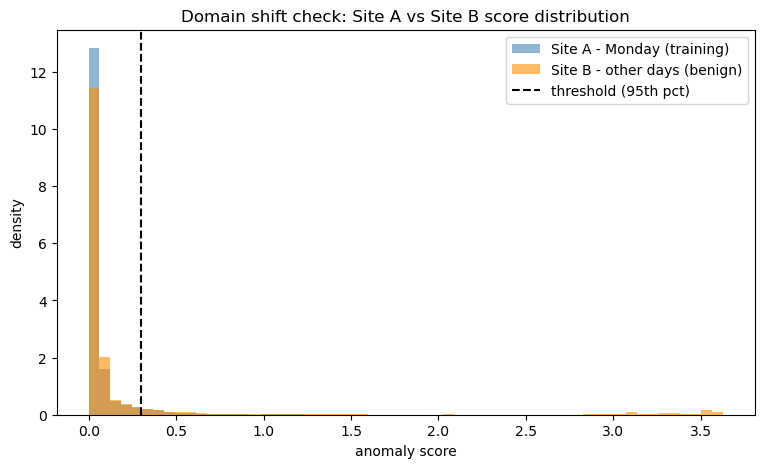

false alarm rate on Site B benign traffic: 11.49%
(if this is way above 5%%, the model trained on Site A is clearly
 flagging Site B's normal traffic as anomalous -- domain shift confirmed)


In [36]:
# does the model's score distribution shift on Site B? 
X_siteB_raw = get_features(siteB_df)[keep].fillna(medians)
X_siteB = scaler.transform(X_siteB_raw)
siteB_scores = ae_error(X_siteB)   # reusing the Autoencoder from earlier

plt.figure(figsize=(9, 5))
bins = np.linspace(0, np.percentile(np.concatenate([s_tr, siteB_scores]), 99), 60)
plt.hist(s_tr, bins=bins, alpha=0.6, density=True, label='Site A - Monday (training)', color='steelblue')
plt.hist(siteB_scores, bins=bins, alpha=0.6, density=True, label='Site B - other days (benign)', color='darkorange')
plt.axvline(np.percentile(s_tr, 95), color='k', ls='--', label='threshold (95th pct)')
plt.xlabel('anomaly score'); plt.ylabel('density')
plt.title('Domain shift check: Site A vs Site B score distribution')
plt.legend()
plt.savefig('domain_shift_check.png', dpi=150, bbox_inches='tight')
plt.show()

false_alarm_rate = 100 * (siteB_scores > np.percentile(s_tr, 95)).mean()
print("false alarm rate on Site B benign traffic: %.2f%%" % false_alarm_rate)
print("(if this is way above 5%%, the model trained on Site A is clearly")
print(" flagging Site B's normal traffic as anomalous -- domain shift confirmed)")

I tested my trained model on Site B's normal traffic and found an 11.49% false-alarm rate more than double the expected ~5%. 
This is notable because my earlier PSI/KS drift checks showed no major per-feature drift, yet the model still behaved noticeably differently on new data.

The takeaway: checking feature-level statistics isn't enough on its own you also need to test the model's actual real-world behavior (false alarm rate) on new data to catch this kind of "quiet" drift before it causes real problems in production.

## AI-generated alert explanations

In [37]:
import os
import google.generativeai as genai

genai.configure(api_key=os.environ["GEMINI_API_KEY"])

model = genai.GenerativeModel("gemini-3.6-flash")


def explain_alert(row_index, model_name, X_raw_df, severity_label, predicted_label):
    row = X_raw_df.iloc[row_index]
    top_features = row.to_dict()

    prompt = f"""You are a network security analyst assistant.
A network intrusion detection model flagged one connection as suspicious.

Model that flagged it: {model_name}
Severity assigned: {severity_label}
Model's prediction: {predicted_label}

Here are some of the connection's feature values:
{top_features}

In 2-3 simple sentences, explain in plain language,this traffic might look suspicious, based on these values. 
If nothing stands out clearly, say so honestly instead of guessing."""

    response = model.generate_content(prompt)
    return response.text


sample_rows = [0, 1, 50]

for i in sample_rows:
    explanation = explain_alert(
        row_index=i,
        model_name='LOF',
        X_raw_df=X_test_raw,
        severity_label=severities['LOF'][i],
        predicted_label='anomaly' if preds['LOF'][i] == 1 else 'benign'
    )
    print(f"Row {i} explanation:\n{explanation}\n")

Row 0 explanation:
This connection appears to be normal web activity over standard encrypted HTTPS (port 443), involving a small exchange of data followed by a 10-second idle pause. Nothing stands out clearly as malicious, which aligns with the model's final prediction of benign traffic. The anomaly detector likely flagged it simply because the long pause relative to the small packet count creates a slightly uncommon timing pattern.

Row 1 explanation:
This network connection appears to be routine DNS traffic (Port 53), consisting of a single request packet (48 bytes) and a single response packet (157 bytes). Honestly, nothing stands out as clearly suspicious or malicious about these values. The anomaly detection model likely flagged it simply because the response timing or packet size slightly differed from the surrounding baseline density.

Row 50 explanation:
This connection appears to be standard, benign DNS traffic on port 53 with typical packet counts and query/response sizes. An

We can also test this explainer on any alert by changing sample_rows to different row numbers
and by swapping model_name='LOF' for any other model (IsolationForest, OneClassSVM, PCA, Autoencoder)